# Comparação de GAPs: André Feijó vs Projeto

Compara os GAPs dos algoritmos `par-it+ref-lin`, `par-it`, `ref-lin` (André Feijó) com o GAP do `aisle_first` (projeto) para cada instância.

In [1]:
# Parâmetro: pasta de resultado a ser analisada
RESULT_DIR = "result_0009"

In [2]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent
RESULTS_PATH = PROJECT_ROOT / 'project' / 'results' / RESULT_DIR
BEST_OBJ_CSV = PROJECT_ROOT / 'best_solutions' / 'best_objectives.csv'
FEIJO_CSV = PROJECT_ROOT / 'best_solutions' / 'andre_feijo.csv'

print(f'Resultados: {RESULTS_PATH}')
print(f'Best objectives: {BEST_OBJ_CSV}')

Resultados: /home/vinicius/Documents/CEFET/TCC/pfc2/project/results/result_0009
Best objectives: /home/vinicius/Documents/CEFET/TCC/pfc2/best_solutions/best_objectives.csv


In [3]:
# Carrega dados de André Feijó
df_feijo = pd.read_csv(FEIJO_CSV)

# Extrai número da instância (remove sufixos * e †)
df_feijo['Instance_num'] = df_feijo['Instance'].str.extract(r'(\d+)').astype(int)

print(f'Instâncias carregadas: {len(df_feijo)}')
df_feijo.head(3)

Instâncias carregadas: 35


,Instance,par-it+ref-lin_t(s),par-it+ref-lin_GAP,par-it_t(s),par-it_GAP,ref-lin_t(s),ref-lin_GAP,Instance_num
0,1*,0,0,0,0,0,0,1
1,2*,0,0,0,0,0,0,2
2,3*,0,0,0,0,0,0,3


In [4]:
# Carrega melhores objetivos conhecidos
df_best = pd.read_csv(BEST_OBJ_CSV)
df_best['instance'] = df_best['instance'].str.replace('.txt', '', regex=False)
print(f'Best objectives carregados: {len(df_best)}')
df_best.head(3)

Best objectives carregados: 50


,dataset,instance,best_objective
0,a,instance_0001,15.0
1,a,instance_0002,2.0
2,a,instance_0003,12.0


In [5]:
# Carrega resultados do projeto
def carregar_resultados(results_dir):
    registros = []
    for dataset in ['a', 'b']:
        dataset_dir = results_dir / dataset
        if not dataset_dir.exists():
            print(f'[AVISO] Dataset {dataset} n\u00e3o encontrado em {dataset_dir}')
            continue
        for csv_file in sorted(dataset_dir.glob('*.csv')):
            df_inst = pd.read_csv(csv_file)
            df_inst['dataset'] = dataset
            df_inst['instance'] = csv_file.stem
            registros.append(df_inst)
    if not registros:
        print('[ERRO] Nenhum CSV encontrado.')
        return pd.DataFrame()
    return pd.concat(registros, ignore_index=True)

df_raw = carregar_resultados(RESULTS_PATH)
print(f'Total de linhas carregadas: {len(df_raw)}')

# Filtra apenas execuções viáveis
df_ok = df_raw[df_raw['status'] == 'feasible'].copy()
print(f'Execu\u00e7\u00f5es com status feasible: {len(df_ok)} de {len(df_raw)}')

df_ok['objective'] = pd.to_numeric(df_ok['objective'], errors='coerce')
df_ok['exec_time'] = pd.to_numeric(df_ok['exec_time'], errors='coerce')
df_ok.head(3)

Total de linhas carregadas: 70
Execuções com status feasible: 63 de 70


,algo_id,run_id,status,objective,items,aisles,exec_time,dataset,instance
0,sa_default,2,feasible,15.0,30,2,8.969,a,instance_0001
1,sa_default,1,feasible,15.0,30,2,9.804,a,instance_0001
2,sa_default,2,feasible,2.0,2,1,2.839,a,instance_0002


In [6]:
# Calcula média do objective por (dataset, instance)
df_agg = df_ok.groupby(['dataset', 'instance'], as_index=False).agg(
    obj_mean=('objective', 'mean'),
    time_mean=('exec_time', 'mean')
).reset_index(drop=True)

print(f'Inst\u00e2ncias agregadas: {len(df_agg)}')
df_agg.head(3)

Instâncias agregadas: 33


,dataset,instance,obj_mean,time_mean
0,a,instance_0001,15.00,9.3865
1,a,instance_0002,2.00,2.8300
2,a,instance_0003,11.25,18.8740


In [7]:
# Merge com best_objectives
df_agg = df_agg.merge(df_best, on=['dataset', 'instance'], how='left')

n_sem_best = df_agg['best_objective'].isna().sum()
if n_sem_best > 0:
    print(f'[AVISO] {n_sem_best} inst\u00e2ncias sem best objective conhecido')

# Calcula GAP do aisle_first (best_known - obj_m\u00e9dio; GAP positivo = pior)
df_agg['aisle_first_GAP'] = df_agg['best_objective'] - df_agg['obj_mean']

print('GAP do aisle_first calculado.')
df_agg[['dataset', 'instance', 'obj_mean', 'best_objective', 'aisle_first_GAP']].head(3)

GAP do aisle_first calculado.


,dataset,instance,obj_mean,best_objective,aisle_first_GAP
0,a,instance_0001,15.00,15.0,0.00
1,a,instance_0002,2.00,2.0,0.00
2,a,instance_0003,11.25,12.0,0.75


In [8]:
# Mapeia n\u00famero da inst\u00e2ncia:
#   1-20  -> dataset 'a', instance_0001-0020
#   21-35 -> dataset 'b', instance_0001-0015
def map_instance_num(row):
    ds = row['dataset']
    inst_num = int(row['instance'].split('_')[1])
    if ds == 'a':
        return inst_num
    elif ds == 'b':
        return inst_num + 20
    return None

df_agg['Instance_num'] = df_agg.apply(map_instance_num, axis=1)

# Merge com df_feijo
cols_feijo = ['Instance_num', 'Instance', 'par-it+ref-lin_GAP', 'par-it_GAP', 'ref-lin_GAP',
              'par-it+ref-lin_t(s)', 'par-it_t(s)', 'ref-lin_t(s)']
df_merged = df_agg.merge(
    df_feijo[cols_feijo],
    on='Instance_num',
    how='inner'
)

print(f'Inst\u00e2ncias pareadas: {len(df_merged)}')
df_merged[['Instance', 'dataset', 'par-it+ref-lin_GAP', 'par-it_GAP', 'ref-lin_GAP', 'aisle_first_GAP']].head(3)

Instâncias pareadas: 33


,Instance,dataset,par-it+ref-lin_GAP,par-it_GAP,ref-lin_GAP,aisle_first_GAP
0,1*,a,0,0,0,0.00
1,2*,a,0,0,0,0.00
2,3*,a,0,0,0,0.75


In [9]:
# Tabela comparativa (ordenada por n\u00famero da inst\u00e2ncia)
df_table = df_merged.sort_values('Instance_num')[[
    'Instance',
    'dataset',
    'best_objective',
    'obj_mean',
    'par-it+ref-lin_GAP',
    'par-it_GAP',
    'ref-lin_GAP',
    'aisle_first_GAP'
]].reset_index(drop=True)

df_table.columns = [
    'Instance',
    'Dataset',
    'Melhor Valor Conhecido',
    'M\u00e9dia Obj',
    'par-it+ref-lin GAP',
    'par-it GAP',
    'ref-lin GAP',
    'aisle_first GAP'
]

display(df_table)

,Instance,Dataset,Melhor Valor Conhecido,Média Obj,par-it+ref-lin GAP,par-it GAP,ref-lin GAP,aisle_first GAP
0,1*,a,15.000000,15.000000,0,0,0,0.000000
1,2*,a,2.000000,2.000000,0,0,0,0.000000
2,3*,a,12.000000,11.250000,0,0,0,0.750000
3,4*,a,3.500000,3.500000,0,0,0,0.000000
4,5,a,177.875000,172.375000,2,0,5,5.500000
5,6,a,691.000000,691.000000,0,0,0,0.000000
6,7,a,392.250000,392.250000,0,0,0,0.000000
7,8,a,162.941176,146.631579,2,0,3,16.309598
8,9*,a,4.416667,3.757576,0,0,0,0.659091
9,10†,a,17.112245,16.921569,1,0,13,0.190676


In [10]:
# Resumo: m\u00e9dia dos GAPs por algoritmo
gap_cols = ['par-it+ref-lin_GAP', 'par-it_GAP', 'ref-lin_GAP', 'aisle_first_GAP']

print('=' * 60)
print(f'{"Algoritmo":<25} {"M\u00e9dia GAP":<15}')
print('=' * 60)
for col in gap_cols:
    media = df_merged[col].mean()
    label = col.replace('_', ' ')
    print(f'{label:<25} {media:<15.4f}')
print('=' * 60)

print(f'\nTotal de inst\u00e2ncias: {len(df_merged)}')

# Contagem de vezes que cada algoritmo encontrou o melhor resultado (GAP = 0)
print(f'\n--- Inst\u00e2ncias com GAP = 0 (melhor resultado conhecido) ---')
for col in gap_cols:
    count_zero = (df_merged[col] == 0).sum()
    label = col.replace('_', ' ')
    print(f'{label:<25}: {count_zero} de {len(df_merged)}')

Algoritmo                 Média GAP      
par-it+ref-lin GAP        0.1515         
par-it GAP                5.0909         
ref-lin GAP               1.8485         
aisle first GAP           2.0439         

Total de instâncias: 33

--- Instâncias com GAP = 0 (melhor resultado conhecido) ---
par-it+ref-lin GAP       : 30 de 33
par-it GAP               : 31 de 33
ref-lin GAP              : 24 de 33
aisle first GAP          : 15 de 33


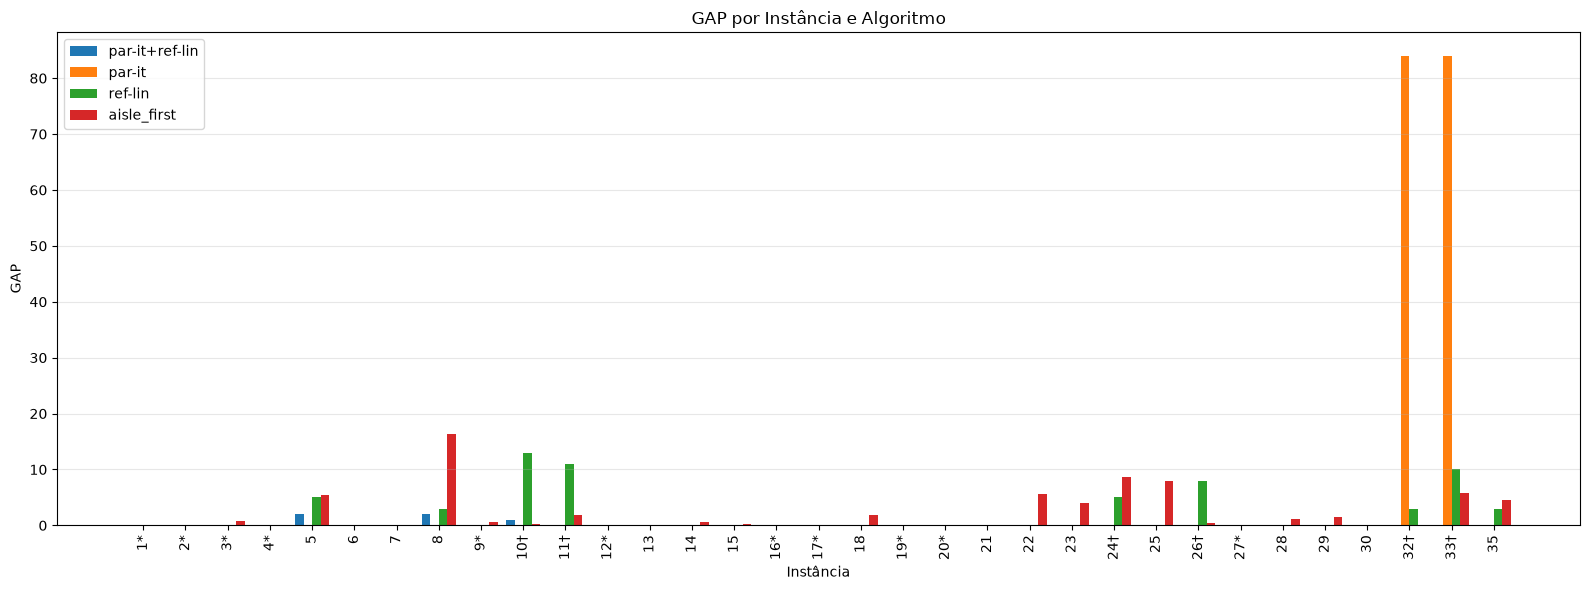

In [11]:
# Gráfico de GAP por instância (barras agrupadas)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 6))

x = range(len(df_table))
width = 0.2

ax.bar([i - 1.5*width for i in x], df_table['par-it+ref-lin GAP'], width, label='par-it+ref-lin')
ax.bar([i - 0.5*width for i in x], df_table['par-it GAP'], width, label='par-it')
ax.bar([i + 0.5*width for i in x], df_table['ref-lin GAP'], width, label='ref-lin')
ax.bar([i + 1.5*width for i in x], df_table['aisle_first GAP'], width, label='aisle_first')

ax.set_xlabel('Instância')
ax.set_ylabel('GAP')
ax.set_title('GAP por Instância e Algoritmo')
ax.set_xticks(x)
ax.set_xticklabels(df_table['Instance'], rotation=90)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
# --- Pareto frontier: Tempo médio vs GAP médio por algoritmo ---
OUTPUT_DIR = PROJECT_ROOT / 'notebooks' / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

def pareto_frontier(df, x_col, y_col, minimize_x=True, minimize_y=True):
    pareto = []
    for i in range(len(df)):
        dominated = False
        for j in range(len(df)):
            if i == j:
                continue
            xi, yi = df.iloc[i][x_col], df.iloc[i][y_col]
            xj, yj = df.iloc[j][x_col], df.iloc[j][y_col]
            better_x = (xj < xi) if minimize_x else (xj > xi)
            better_y = (yj < yi) if minimize_y else (yj > yi)
            if better_x and better_y:
                dominated = True
                break
            if (xj == xi and better_y) or (yj == yi and better_x):
                dominated = True
                break
        pareto.append(not dominated)
    return pareto

# Monta DataFrame com média de tempo e GAP por algoritmo
pareto_data = []

# aisle_first
pareto_data.append({
    'Algoritmo': 'aisle_first',
    'Tempo Médio (s)': df_merged['time_mean'].mean(),
    'GAP Médio': df_merged['aisle_first_GAP'].mean()
})

# Algoritmos de André Feijó
for algo_prefix, algo_label in [
    ('par-it+ref-lin', 'par-it+ref-lin'),
    ('par-it', 'par-it'),
    ('ref-lin', 'ref-lin')
]:
    time_col = f'{algo_prefix}_t(s)'
    gap_col = f'{algo_prefix}_GAP'
    pareto_data.append({
        'Algoritmo': algo_label,
        'Tempo Médio (s)': df_merged[time_col].mean(),
        'GAP Médio': df_merged[gap_col].mean()
    })

df_pareto = pd.DataFrame(pareto_data)

# Calcula fronteira de Pareto (minimizar ambos os eixos)
df_pareto['Pareto'] = pareto_frontier(
    df_pareto, 'Tempo Médio (s)', 'GAP Médio',
    minimize_x=True, minimize_y=True
)

n_front = df_pareto['Pareto'].sum()
print(f'Total de algoritmos na fronteira de Pareto: {n_front} de {len(df_pareto)}')
print()

df_pareto_exibir = df_pareto.sort_values('GAP Médio').reset_index(drop=True)
display(df_pareto_exibir)

# Salva CSV
path_csv = OUTPUT_DIR / 'pareto_frontier_compare.csv'
df_pareto_exibir.to_csv(path_csv, index=False)
print('Pareto frontier salva em:', path_csv)

Total de algoritmos na fronteira de Pareto: 2 de 4



,Algoritmo,Tempo Médio (s),GAP Médio,Pareto
0,par-it+ref-lin,175.636364,0.151515,True
1,ref-lin,281.242424,1.848485,False
2,aisle_first,450.789576,2.043904,False
3,par-it,169.333333,5.090909,True


Pareto frontier salva em: /home/vinicius/Documents/CEFET/TCC/pfc2/notebooks/output/pareto_frontier_compare.csv


Gráfico salvo em: /home/vinicius/Documents/CEFET/TCC/pfc2/notebooks/output/pareto_frontier_compare.png


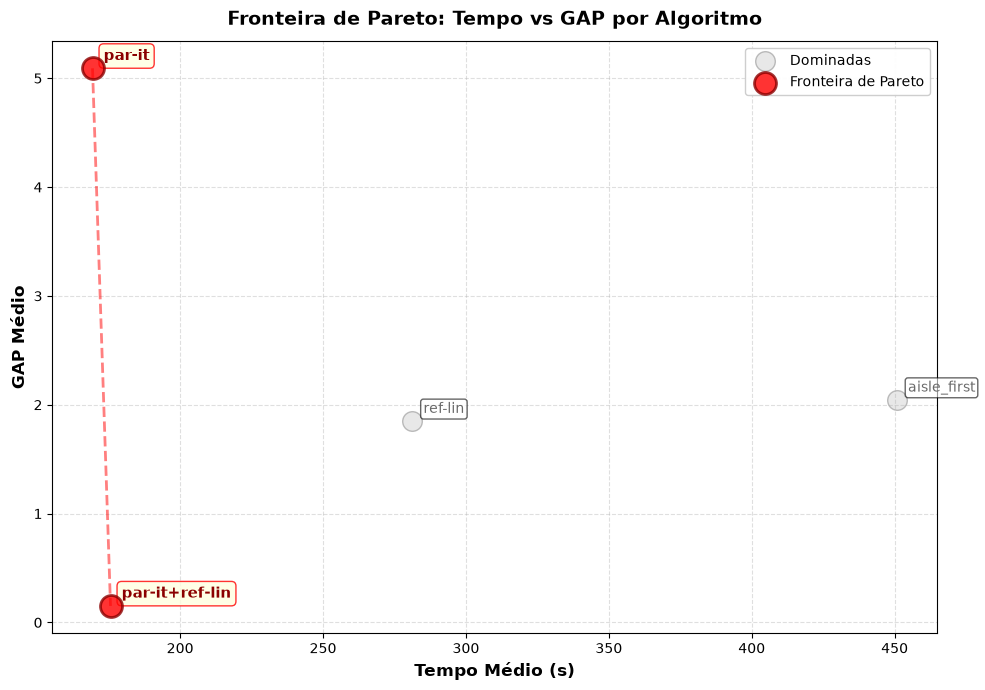

In [13]:
# --- Scatter plot: Pareto frontier (Tempo vs GAP) ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

pareto = df_pareto[df_pareto['Pareto']]
dominated = df_pareto[~df_pareto['Pareto']]

ax.scatter(dominated['Tempo Médio (s)'], dominated['GAP Médio'],
           s=200, alpha=0.5, c='lightgray', edgecolors='gray', linewidth=1, label='Dominadas')
ax.scatter(pareto['Tempo Médio (s)'], pareto['GAP Médio'],
           s=250, alpha=0.8, c='red', edgecolors='darkred', linewidth=2,
           label='Fronteira de Pareto', zorder=5)

pareto_sorted = pareto.sort_values('Tempo Médio (s)')
ax.plot(pareto_sorted['Tempo Médio (s)'], pareto_sorted['GAP Médio'],
        'r--', alpha=0.5, linewidth=2, zorder=4)

def add_label(row):
    label = row['Algoritmo']
    if row['Pareto']:
        ax.annotate(label, (row['Tempo Médio (s)'], row['GAP Médio']),
                    textcoords='offset points', xytext=(8, 6), ha='left',
                    fontsize=11, fontweight='bold', color='darkred',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                              alpha=0.8, edgecolor='red'))
    else:
        ax.annotate(label, (row['Tempo Médio (s)'], row['GAP Médio']),
                    textcoords='offset points', xytext=(8, 6), ha='left',
                    fontsize=10, color='dimgray',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6))

df_pareto.apply(add_label, axis=1)

ax.set_xlabel('Tempo Médio (s)', fontsize=12, fontweight='bold')
ax.set_ylabel('GAP Médio', fontsize=12, fontweight='bold')
ax.set_title('Fronteira de Pareto: Tempo vs GAP por Algoritmo', fontsize=14, fontweight='bold', pad=12)
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
path_png = OUTPUT_DIR / 'pareto_frontier_compare.png'
fig.savefig(path_png, dpi=150, bbox_inches='tight')
print('Gráfico salvo em:', path_png)
plt.show()